# Coffee Shop Sales Analysis

## Objective
The objective of this project is to analyze coffee shop sales data to identify sales trends, customer purchasing behavior, product performance, and store performance using Python (Pandas & Matplotlib).

## Tools Used
- Python
- Pandas
- Matplotlib
- Jupyter Notebook

# 1. Import Libraries

The required Python libraries are imported to perform data manipulation, analysis, and visualization throughout the project.


In [6]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# 2. Load Dataset

The Coffee Shop Sales dataset is loaded into a Pandas DataFrame to begin the analysis. This dataset contains transaction-level information, including transaction date and time, store location, product details, quantity sold, and unit price. It serves as the foundation for data cleaning, feature engineering, and exploratory data analysis.

In [7]:
# import dataframe

df = pd.read_csv("Coffee_shop_sales_utfb.csv")

# 3. Data Understanding

Before performing data cleaning and analysis, it is important to understand the structure and characteristics of the dataset. This step helps identify the number of rows and columns, data types, missing values, summary statistics, and overall data quality.

In [8]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,1/1/2023,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,1/1/2023,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,1/1/2023,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,1/1/2023,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,1/1/2023,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [9]:
df.shape


(149116, 11)

In [10]:
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail'],
      dtype='str')

In [11]:
df.dtypes

transaction_id        int64
transaction_date        str
transaction_time        str
transaction_qty       int64
store_id              int64
store_location          str
product_id            int64
unit_price          float64
product_category        str
product_type            str
product_detail          str
dtype: object

In [12]:
df.describe()

,transaction_id,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,1.438276,5.342063,47.918607,3.382219
std,43153.600016,0.542509,2.074241,17.930020,2.658723
min,1.000000,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2.000000,8.000000,60.000000,3.750000
max,149456.000000,8.000000,8.000000,87.000000,45.000000


# 4. Data Cleaning & Feature Engineering

This section prepares the dataset for analysis by converting data types and creating new features required for revenue and sales analysis.

In [ ]:
# Date Conversion

df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [14]:
#Time conversion


df['transaction_time'] = pd.to_datetime(df['transaction_time'], format = '%H:%M:%S')

In [ ]:
df['transaction_time'] = pd.to_datetime(
    df['transaction_time']
).dt.time

In [16]:
# Month

df['Month'] = df['transaction_date'].dt.month_name()

In [17]:
# Month number

df['Month_No'] = df['transaction_date'].dt.month

In [18]:
# Weekday number

df['Weekday_No'] = df['transaction_date'].dt.weekday

In [19]:
# Day name

df['Day'] = df['transaction_date'].dt.day_name()

In [20]:
# Hour

df['Hour'] = df['transaction_time'].apply(lambda x: x.hour)

#df['Hour'] = df['transaction_time'].dt.hour


In [21]:
# Data type conversion
df['transaction_time'] = pd.to_datetime(
    df['transaction_time'],
    format='%H:%M:%S'
)

In [22]:
#total bill column 
df['Total_Bill'] = df['transaction_qty']*df['unit_price']

In [23]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[us]
 2   transaction_time  149116 non-null  datetime64[us]
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  str           
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  str           
 9   product_type      149116 non-null  str           
 10  product_detail    149116 non-null  str           
 11  Month             149116 non-null  str           
 12  Month_No          149116 non-null  int32         
 13  Weekday_No        149116 non-null  int32         
 14  Day            

In [24]:
df.isnull().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
Month               0
Month_No            0
Weekday_No          0
Day                 0
Hour                0
Total_Bill          0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Month,Month_No,Weekday_No,Day,Hour,Total_Bill
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,January,1,6,Sunday,7,6.0
1,2,2023-01-01,1900-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,January,1,6,Sunday,7,6.2
2,3,2023-01-01,1900-01-01 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,January,1,6,Sunday,7,9.0
3,4,2023-01-01,1900-01-01 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,January,1,6,Sunday,7,2.0
4,5,2023-01-01,1900-01-01 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,January,1,6,Sunday,7,6.2


In [27]:
df.dtypes

transaction_id               int64
transaction_date    datetime64[us]
transaction_time    datetime64[us]
transaction_qty              int64
store_id                     int64
store_location                 str
product_id                   int64
unit_price                 float64
product_category               str
product_type                   str
product_detail                 str
Month                          str
Month_No                     int32
Weekday_No                   int32
Day                            str
Hour                         int64
Total_Bill                 float64
dtype: object

In [28]:
#lets figure out
#1.total_transactions
#2. total revenue
#3. total quantity sold
#4. Average order value
#5. Monthly sales 

# 5. Revenue Analysis


This section analyzes the overall revenue generated by the coffee shop. The objective is to identify sales trends across different time periods, helping understand business performance and customer purchasing patterns.

# Total transactions :


In [29]:
total_transactions = df['transaction_id'].nunique()
print(f"Total Transactions : {total_transactions}")

Total Transactions : 149116


# Total revenue :

In [ ]:
total_revenue = df['Total_Bill'].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $698,812.33


# Total quantity sold :


In [31]:
Total_Quantity = df['transaction_qty'].sum()
print(f'Total Quantity = {Total_Quantity}')

Total Quantity = 214470


In [32]:
#4. Average order value

Average_Order_Value = df['Total_Bill'].mean()
print(f'Average order value : {Average_Order_Value:.2f}')

Average order value : 4.69


## Monthly Revenue Trend :

In [ ]:
monthly_sales = df.groupby(['Month'])['Total_Bill'].sum().reset_index()
monthly_sales

,Month,Total_Bill
0,April,118941.08
1,February,76145.19
2,January,81677.74
3,June,166485.88
4,March,98834.68
5,May,156727.76


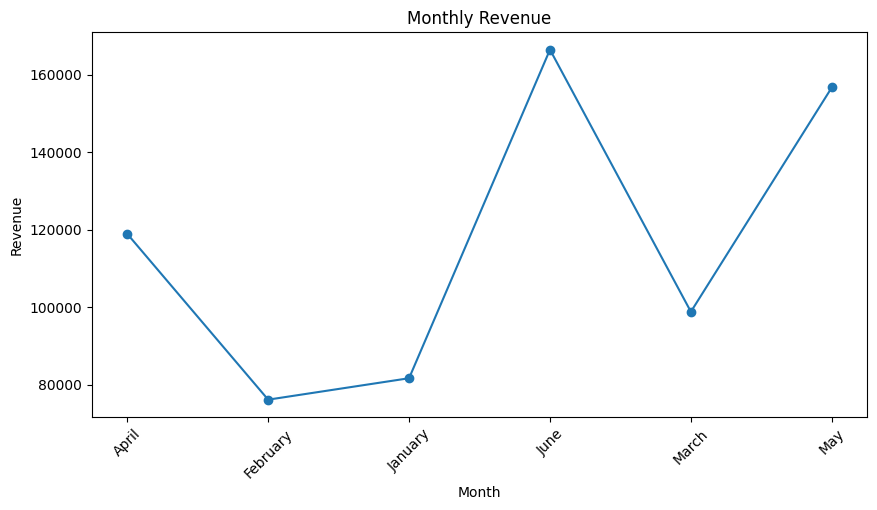

In [34]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Month'], monthly_sales['Total_Bill'], marker='o')

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

In [35]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Month,Month_No,Weekday_No,Day,Hour,Total_Bill
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,January,1,6,Sunday,7,6.0
1,2,2023-01-01,1900-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,January,1,6,Sunday,7,6.2
2,3,2023-01-01,1900-01-01 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,January,1,6,Sunday,7,9.0
3,4,2023-01-01,1900-01-01 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,January,1,6,Sunday,7,2.0
4,5,2023-01-01,1900-01-01 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,January,1,6,Sunday,7,6.2



# Monthly Sales :


In [83]:
monthly_sales

,Month,Total_Bill
0,April,118941.08
1,February,76145.19
2,January,81677.74
3,June,166485.88
4,March,98834.68
5,May,156727.76


In [37]:
df.groupby(['Month_No','Month'])['Total_Bill'].sum().reset_index().sort_values('Month_No')

,Month_No,Month,Total_Bill
0,1,January,81677.74
1,2,February,76145.19
2,3,March,98834.68
3,4,April,118941.08
4,5,May,156727.76
5,6,June,166485.88


# Weekend sales :

In [38]:
weekend_sales = df[df['Day'].isin(['Saturday','Sunday'])]

In [39]:
df['Day'].value_counts()

Day
Friday       21701
Thursday     21654
Monday       21643
Wednesday    21310
Tuesday      21202
Sunday       21096
Saturday     20510
Name: count, dtype: int64

In [40]:
df[['Weekday_No', 'Day']].drop_duplicates().sort_values('Weekday_No').reset_index(drop=True)

,Weekday_No,Day
0,0,Monday
1,1,Tuesday
2,2,Wednesday
3,3,Thursday
4,4,Friday
5,5,Saturday
6,6,Sunday


# Weeknd revenue :


In [41]:
#weeknd revenue
weekend_revenue = weekend_sales['Total_Bill'].sum()
print(f'weekday Revenue :{weekend_revenue}')

weekday Revenue :195224.78999999998


In [42]:
weekend_sales.groupby('product_detail')['transaction_qty'].sum().reset_index()

,product_detail,transaction_qty
0,Almond Croissant,532
1,Brazilian - Organic,60
2,Brazilian Lg,1263
3,Brazilian Rg,1231
4,Brazilian Sm,1198
...,...,...
75,Sustainably Grown Organic Lg,1257
76,Sustainably Grown Organic Rg,1216
77,Traditional Blend Chai,44
78,Traditional Blend Chai Lg,1140


# 6. Product Analysis

This section evaluates product performance by identifying the best-selling and highest revenue-generating products. The analysis helps understand customer preferences and highlights products that contribute the most to overall sales.

In [43]:
df['product_detail'].nunique()

80

In [44]:
weekend_sales = df[df['Day'].isin(['Saturday', 'Sunday'])]

In [45]:
weekend_drinks = weekend_sales.groupby('product_detail')['transaction_qty'].sum()

In [46]:
weekend_drinks = weekend_drinks.reset_index().sort_values(by='transaction_qty', ascending = False)

In [47]:
weekend_drinks.reset_index()

,index,product_detail,transaction_qty
0,24,Earl Grey Rg,1332
1,54,Morning Sunrise Chai Rg,1300
2,47,Latte,1293
3,79,Traditional Blend Chai Rg,1283
4,33,Ethiopia Sm,1281
...,...,...,...
75,52,Morning Sunrise Chai,42
76,62,Peppermint,41
77,36,Guatemalan Sustainably Grown,40
78,70,Spicy Eye Opener Chai,34


### 📊 Business Insights

- **Earl Grey Rg** emerged as the best-selling weekend drink with **1,332 units sold**, indicating strong customer preference during weekends.

- Tea-based beverages, including **Morning Sunrise Chai Rg** and **Traditional Blend Chai Rg**, ranked among the top-selling weekend drinks, suggesting that customers frequently prefer tea options over weekends.

- Popular weekend beverages should be prioritized for inventory management and featured in weekend promotions to ensure product availability and maximize sales.

## Monthly Revenue :

In [ ]:
monthly_sales

,Month,Total_Bill
0,April,118941.08
1,February,76145.19
2,January,81677.74
3,June,166485.88
4,March,98834.68
5,May,156727.76


# Monthly Revenue Generated :


In [49]:
monthly_revenue = df.groupby(['Month_No','Month'])['Total_Bill'].sum().reset_index().sort_values('Month_No')

In [50]:
monthly_revenue

,Month_No,Month,Total_Bill
0,1,January,81677.74
1,2,February,76145.19
2,3,March,98834.68
3,4,April,118941.08
4,5,May,156727.76
5,6,June,166485.88


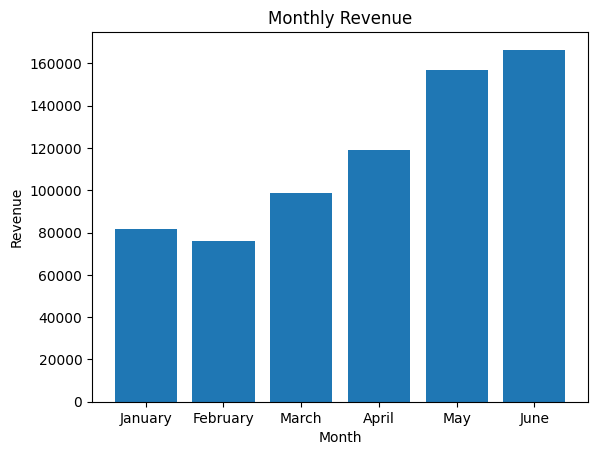

In [51]:
import matplotlib.pyplot as plt
plt.Figure(figsize=(10,5))

plt.bar(monthly_revenue['Month'],
        monthly_revenue['Total_Bill'])

plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

           

### 📊 Business Insights

- **June** generated the highest monthly revenue (**$166,485.88**), while **February** recorded the lowest revenue (**$76,145.19**).

- Monthly revenue showed an overall upward trend from January to June, indicating steady business growth and increasing customer demand.

- The significant increase in revenue during May and June suggests higher customer activity, making these months ideal for promotional campaigns and inventory planning.

# Hourly Revenue :


In [52]:
hourly_revenue= df.groupby(['Hour'])['Total_Bill'].sum().reset_index().sort_values(by ='Hour', ascending = True)

In [53]:
hourly_revenue

,Hour,Total_Bill
0,6,21900.27
1,7,63526.47
2,8,82699.87
3,9,85169.53
4,10,88673.39
5,11,46319.14
6,12,40192.79
7,13,40367.45
8,14,41304.74
9,15,41733.10


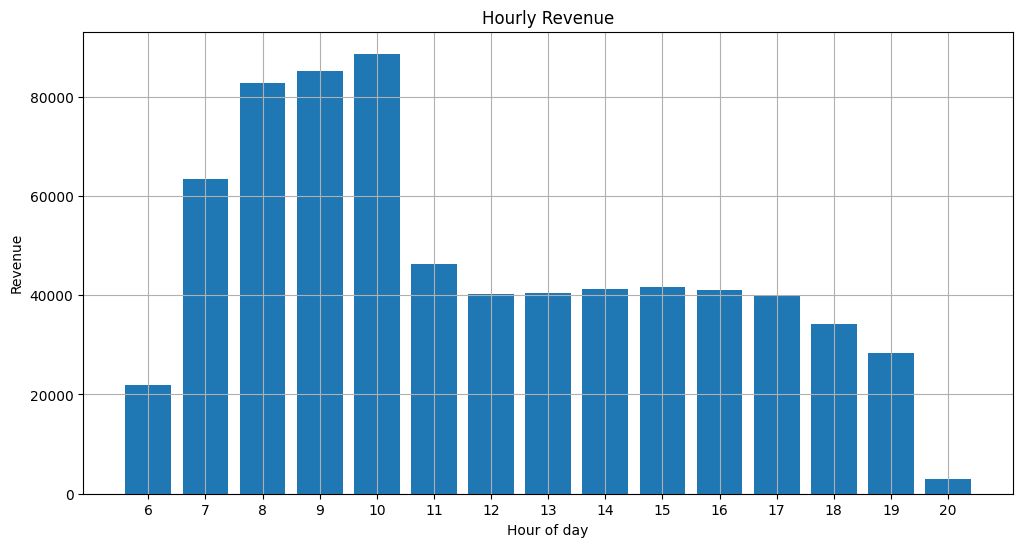

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    hourly_revenue['Hour'],
         hourly_revenue['Total_Bill'],
        )

plt.title('Hourly Revenue')
plt.xlabel('Hour of day')
plt.ylabel('Revenue')

plt.xticks(hourly_revenue['Hour'])
plt.grid(True)

plt.show()

### 📊 Business Insights

- **10:00 AM** recorded the highest hourly revenue (**$88,673.39**), making it the peak sales hour of the day.

- Revenue increased steadily from **6:00 AM to 10:00 AM**, indicating that customer demand is strongest during the morning hours.

- After **10:00 AM**, revenue declined and remained relatively stable throughout the afternoon, suggesting lower customer traffic after the morning rush.

# Daily Revenue :


In [55]:


Daily_Revenue = df.groupby(['Weekday_No','Day'])['Total_Bill'].sum().reset_index().sort_values('Weekday_No')

In [56]:
Daily_Revenue

,Weekday_No,Day,Total_Bill
0,0,Monday,101677.28
1,1,Tuesday,99455.94
2,2,Wednesday,100313.54
3,3,Thursday,100767.78
4,4,Friday,101373.00
5,5,Saturday,96894.48
6,6,Sunday,98330.31


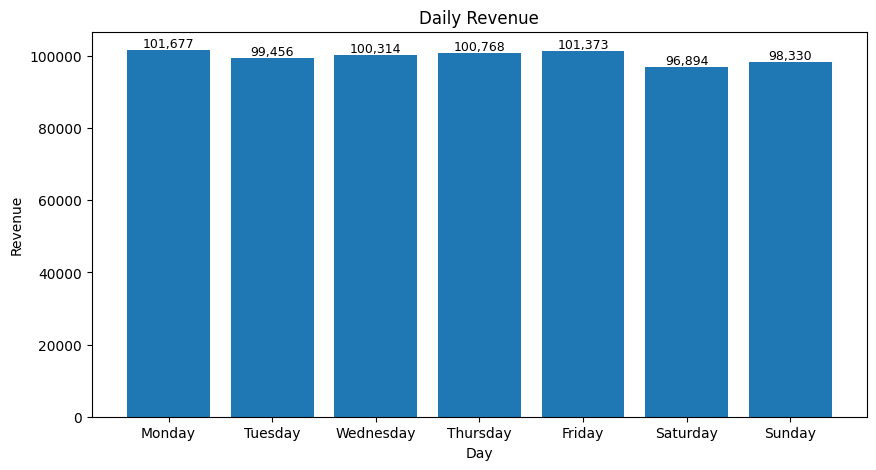

In [57]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    Daily_Revenue['Day'],
    Daily_Revenue['Total_Bill']
)

plt.title('Daily Revenue')
plt.xlabel('Day')
plt.ylabel('Revenue')

# Value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.show()

### 📊 Business Insights

- Revenue remained relatively consistent across weekdays, with only minor variations between Monday and Friday.

- **Monday** generated the highest revenue (**$101,677.28**) among the weekdays shown, while **Tuesday** recorded the lowest (**$99,455.94**).

- The balanced daily revenue indicates stable customer demand throughout the week, suggesting consistent business performance rather than dependence on a single day.

# Best Selling Product :


In [58]:
Best_product = df.groupby(['product_detail'])['transaction_qty'].sum().reset_index().sort_values(by = 'transaction_qty', ascending = False)

Best_product

,product_detail,transaction_qty
24,Earl Grey Rg,4708
20,Dark chocolate Lg,4668
54,Morning Sunrise Chai Rg,4643
47,Latte,4602
64,Peppermint Rg,4564
...,...,...
42,Jamacian Coffee River,146
22,Earl Grey,142
36,Guatemalan Sustainably Grown,134
70,Spicy Eye Opener Chai,122


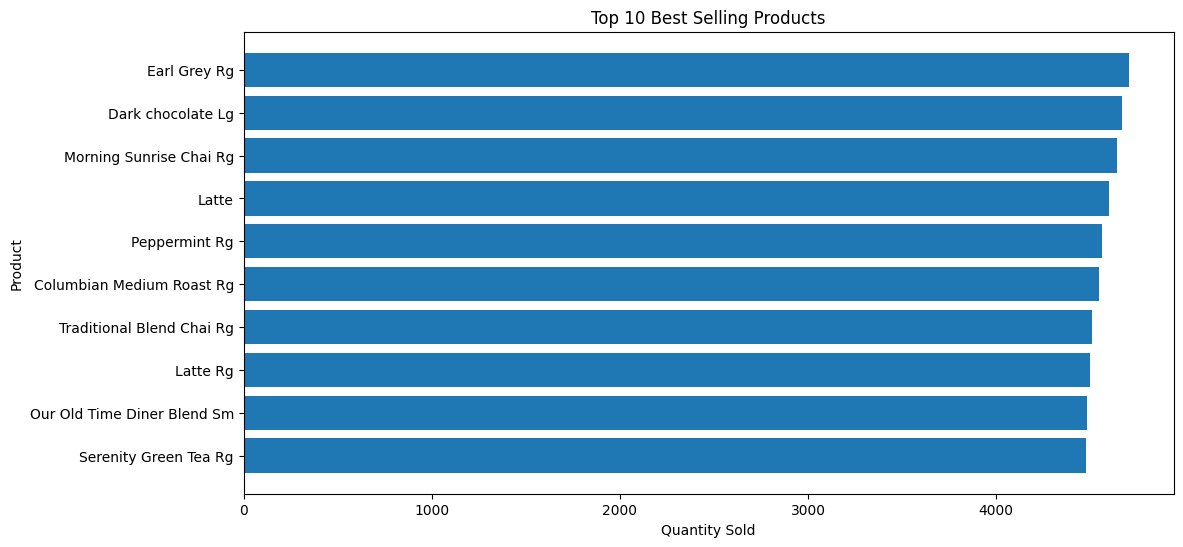

In [59]:
top10 = Best_product.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10['product_detail'],
    top10['transaction_qty']
)

plt.title('Top 10 Best Selling Products')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')

plt.gca().invert_yaxis()

plt.show()

### 📊 Business Insights

- **Earl Grey Rg** emerged as the best-selling product, with **4,708 units sold**, making it the most preferred product among customers.

- Beverage products dominated the top-selling list, with **Dark Chocolate Lg, Morning Sunrise Chai Rg, Latte, and Peppermint Rg** also recording strong sales volumes, indicating high customer demand for hot beverages.

- The significant gap between the highest-selling and lowest-selling products suggests varying customer preferences. Low-performing products should be reviewed for promotional strategies or menu optimization.

# Highest Revenue Product :

In [84]:
highest_revenue_product = df.groupby('product_detail')['Total_Bill'].sum().reset_index().sort_values(by = 'Total_Bill', ascending = False)

highest_revenue_product

,product_detail,Total_Bill
75,Sustainably Grown Organic Lg,21151.75
20,Dark chocolate Lg,21006.00
48,Latte Rg,19112.25
6,Cappuccino Lg,17641.75
53,Morning Sunrise Chai Lg,17384.00
...,...,...
49,Lemon Grass,1360.40
36,Guatemalan Sustainably Grown,1340.00
70,Spicy Eye Opener Chai,1335.90
22,Earl Grey,1270.90


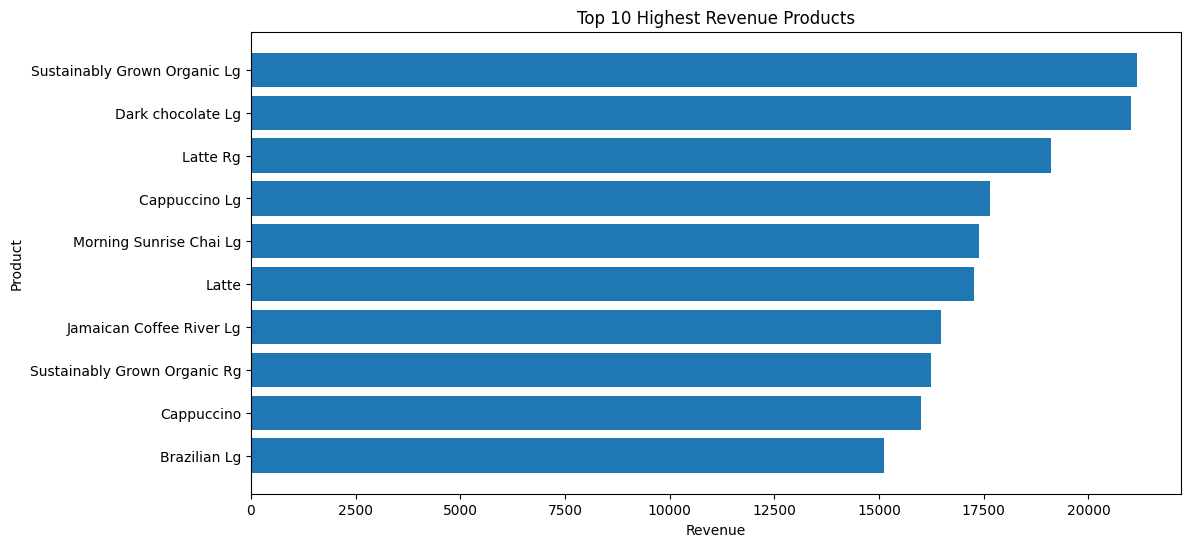

In [61]:
top10 = highest_revenue_product.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10['product_detail'],
    top10['Total_Bill']
)

plt.title('Top 10 Highest Revenue Products')
plt.xlabel('Revenue')
plt.ylabel('Product')

plt.gca().invert_yaxis()

plt.show()

### 📊 Business Insights

- **Sustainably Grown Organic Lg** generated the highest revenue (**$21,151.75**), making it the most valuable product in terms of sales contribution.

- Premium beverages such as **Dark Chocolate Lg, Latte Rg, Cappuccino Lg, and Morning Sunrise Chai Lg** also ranked among the top revenue-generating products, indicating strong customer demand for higher-value beverages.

- The highest revenue-generating products contribute significantly to the overall business income. Prioritizing these products through effective inventory management and promotional campaigns can help maximize profitability.

# Store Revenue :


In [62]:
 

store_revenue = df.groupby('store_location')['Total_Bill'].sum().reset_index().sort_values(by = 'Total_Bill', ascending= False)

store_revenue.reset_index()

,index,store_location,Total_Bill
0,1,Hell's Kitchen,236511.17
1,0,Astoria,232243.91
2,2,Lower Manhattan,230057.25


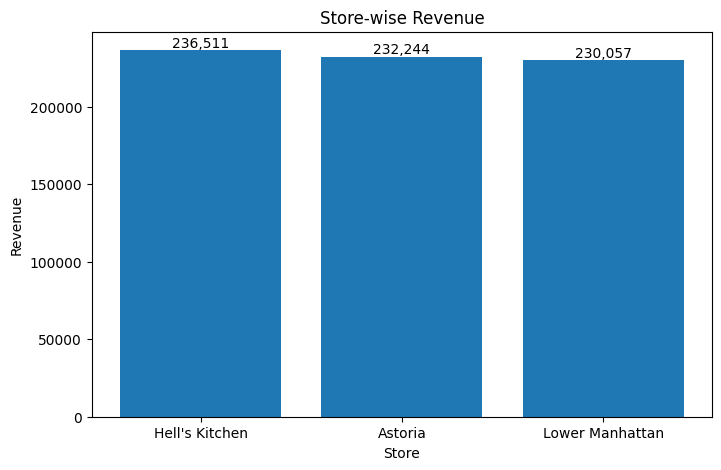

In [63]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    store_revenue['store_location'],
    store_revenue['Total_Bill']
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha='center',
        va='bottom'
    )

plt.title('Store-wise Revenue')
plt.xlabel('Store')
plt.ylabel('Revenue')

plt.show()


Revenue is relatively balanced across all three store locations, indicating consistent business performance with no single store dominating sales.

### 📊 Business Insights

- **Hell's Kitchen** generated the highest revenue (**$236,511.17**), making it the best-performing store among all locations.

- **Astoria** and **Lower Manhattan** recorded revenues of **$232,243.91** and **$230,057.25**, respectively, indicating that all three stores delivered consistently strong sales performance.

- The relatively small difference in revenue across the three stores suggests balanced customer demand and consistent operational performance across locations.

# Which product category generates the highest revenue? :

In [64]:
Category_revenue = df.groupby('product_category')['Total_Bill'].sum().reset_index().sort_values(by = "Total_Bill", ascending= False)

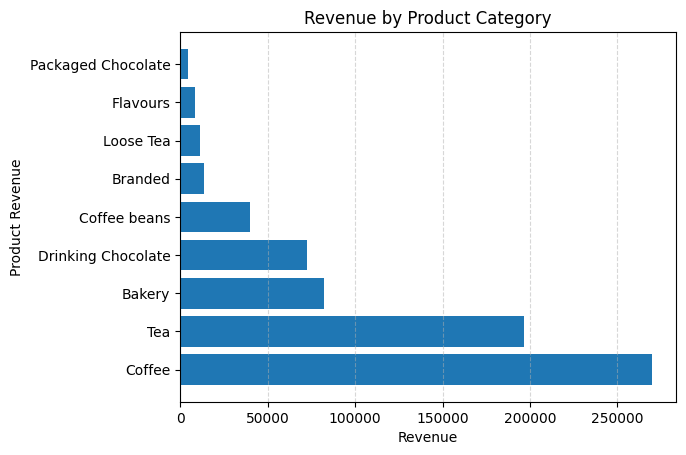

In [65]:
plt.Figure(figsize= (10,5))

plt.barh(
    Category_revenue['product_category'],
    Category_revenue['Total_Bill']
)

plt.title('Revenue by Product Category')
plt.xlabel('Revenue')
plt.ylabel('Product Revenue')


plt.gca().invert_yaxis

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()




# Which product category sells the highest quantity? :

In [66]:
Category_quantity = df.groupby('product_category')['transaction_qty'].sum().reset_index().sort_values(by = 'transaction_qty', ascending = False)

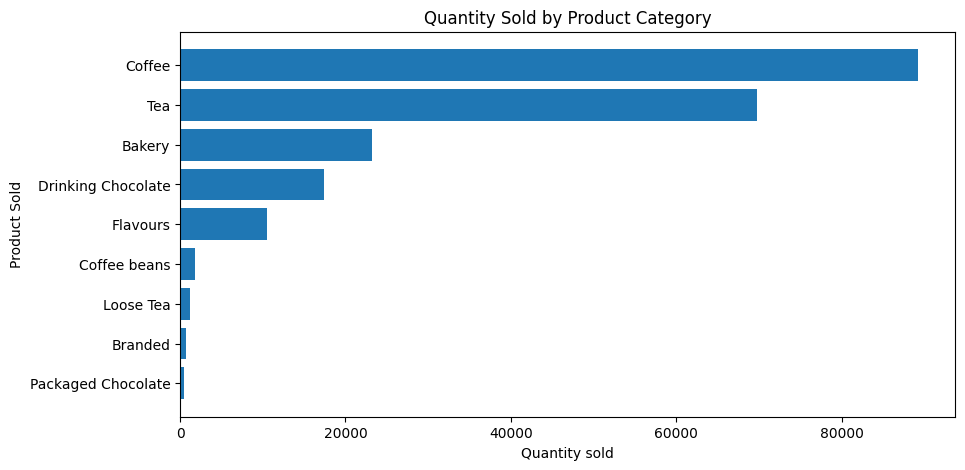

In [67]:
plt.figure(figsize= (10,5))

plt.barh(
    Category_quantity['product_category'],
    Category_quantity['transaction_qty']
)

plt.title('Quantity Sold by Product Category')
plt.xlabel('Quantity sold')
plt.ylabel('Product Sold')

plt.gca().invert_yaxis()

plt.show()

# Which product types generate the highest revenue? :


In [68]:
type_revenue = df.groupby('product_type')['Total_Bill'].sum().reset_index().sort_values(by = 'Total_Bill', ascending = False)

<function matplotlib.pyplot.show(close=None, block=None)>

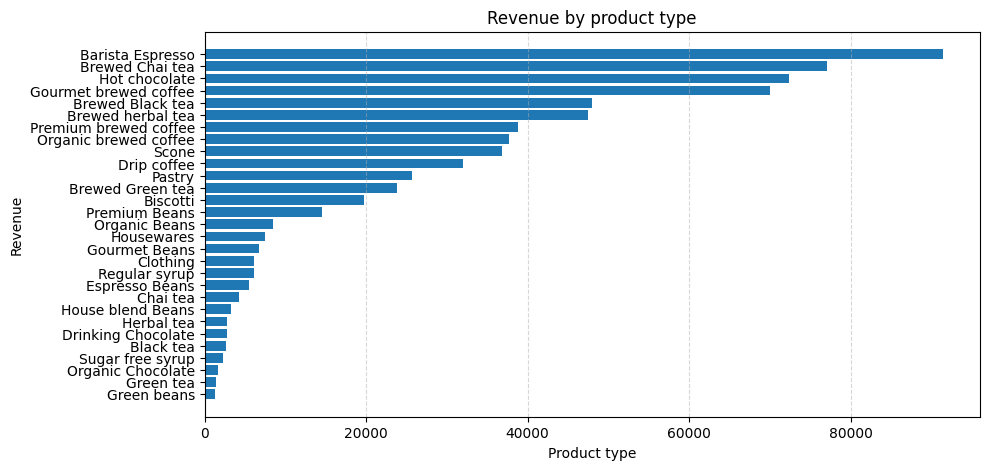

In [69]:
plt.figure(figsize= (10,5))

plt.barh(
    type_revenue['product_type'],
    type_revenue['Total_Bill']
)

plt.title('Revenue by product type')
plt.ylabel('Revenue')
plt.xlabel('Product type')

plt.gca().invert_yaxis()

plt.grid(axis= 'x', linestyle  = '--', alpha= 0.5 )

plt.show

# Which product types are sold the most? :


In [70]:
type_quantity = df.groupby('product_type')['transaction_qty'].sum().reset_index().sort_values(by = "transaction_qty", ascending =  False)

type_quantity.head(10)

,product_type,transaction_qty
4,Brewed Chai tea,26250
13,Gourmet brewed coffee,25973
0,Barista Espresso,24943
3,Brewed Black tea,17462
17,Hot chocolate,17457
6,Brewed herbal tea,17328
22,Organic brewed coffee,13012
10,Drip coffee,12891
25,Premium brewed coffee,12431
27,Scone,10465


<function matplotlib.pyplot.show(close=None, block=None)>

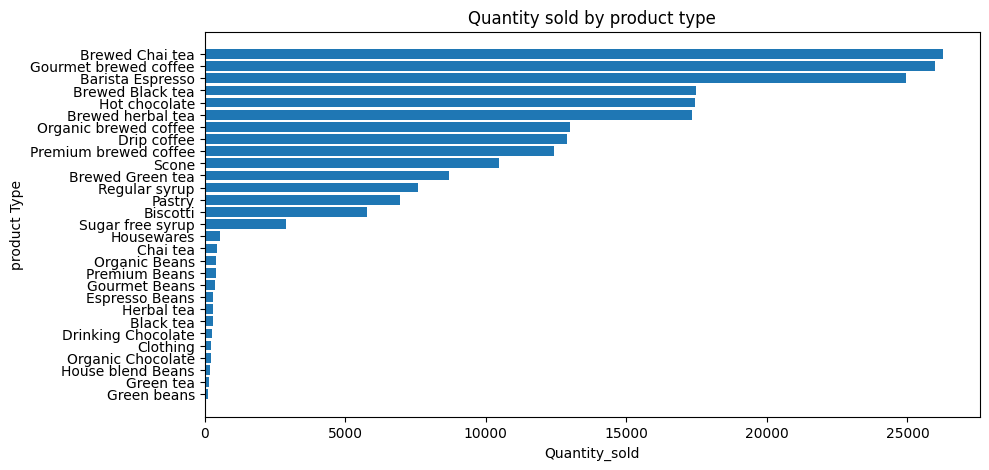

In [71]:
plt.figure (figsize= (10,5))

plt.barh(
    type_quantity['product_type'],
    type_quantity['transaction_qty']
)

plt.title('Quantity sold by product type')
plt.xlabel('Quantity_sold')
plt.ylabel('product Type')

plt.gca().invert_yaxis()

plt.show

# Which product generates the highest average revenue per transaction? :

In [72]:
avg_product_revenue = (
    df.groupby('product_detail')['Total_Bill']
      .mean()
      .reset_index()
      .sort_values(by='Total_Bill', ascending=False)
)

avg_product_revenue.head(10)

,product_detail,Total_Bill
12,Civet Cat,61.578947
41,I Need My Bean! T-shirt,27.886878
56,Organic Decaf Blend,22.609223
30,Ethiopia,21.000000
65,Primo Espresso Roast,20.450000
42,Jamacian Coffee River,19.750000
1,Brazilian - Organic,18.430622
57,Our Old Time Diner Blend,18.000000
13,Columbian Medium Roast,15.000000
40,I Need My Bean! Latte cup,14.832237


# What is the best-selling product at each store location? :


In [73]:
best_store_product = df.groupby(['store_location','product_detail'])['transaction_qty'].sum().reset_index().sort_values(by= 'transaction_qty', ascending = False)

best_store_product.head(10)

,store_location,product_detail,transaction_qty
140,Hell's Kitchen,Ouro Brasileiro shot,1854
20,Astoria,Dark chocolate Lg,1755
24,Astoria,Earl Grey Rg,1725
63,Astoria,Peppermint Rg,1673
70,Astoria,Spicy Eye Opener Chai Lg,1634
33,Astoria,Ethiopia Sm,1619
15,Astoria,Columbian Medium Roast Rg,1613
148,Hell's Kitchen,Serenity Green Tea Rg,1601
133,Hell's Kitchen,Morning Sunrise Chai Rg,1589
222,Lower Manhattan,Peppermint Lg,1582


In [74]:
best_product_each_store = (best_store_product.sort_values(by = ['store_location','transaction_qty'], ascending = [True,False])

.groupby('store_location').head(1))

best_product_each_store

,store_location,product_detail,transaction_qty
20,Astoria,Dark chocolate Lg,1755
140,Hell's Kitchen,Ouro Brasileiro shot,1854
222,Lower Manhattan,Peppermint Lg,1582


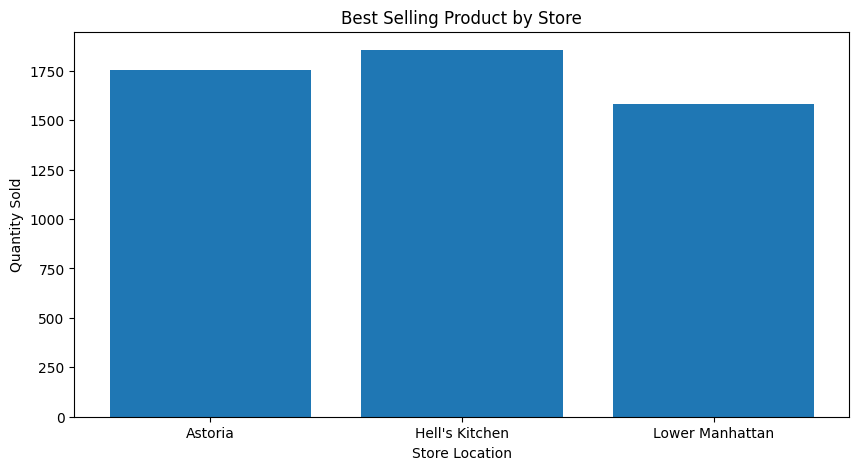

In [75]:
plt.figure(figsize=(10,5))

plt.bar(
    best_product_each_store['store_location'],
    best_product_each_store['transaction_qty']
)

plt.title('Best Selling Product by Store')
plt.xlabel('Store Location')
plt.ylabel('Quantity Sold')

plt.show()

Each store has its own best-selling product.
Customer preferences vary across store locations.
Store-specific inventory planning can reduce stock shortages.
Localized marketing campaigns can improve product sales.

# Weekend vs Weekday Analysis :

In [76]:
df['Day_type'] = df['Day'].apply(lambda x: 'Weekend' if x in ['Saturday','Sunday']else "Weekday")

In [77]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Month,Month_No,Weekday_No,Day,Hour,Total_Bill,Day_type
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,January,1,6,Sunday,7,6.0,Weekend
1,2,2023-01-01,1900-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,January,1,6,Sunday,7,6.2,Weekend
2,3,2023-01-01,1900-01-01 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,January,1,6,Sunday,7,9.0,Weekend
3,4,2023-01-01,1900-01-01 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,January,1,6,Sunday,7,2.0,Weekend
4,5,2023-01-01,1900-01-01 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,January,1,6,Sunday,7,6.2,Weekend


In [78]:
weekend_weekday_revenue = (df.groupby('Day_type')['Total_Bill'].sum().reset_index())

weekend_weekday_revenue

,Day_type,Total_Bill
0,Weekday,503587.54
1,Weekend,195224.79


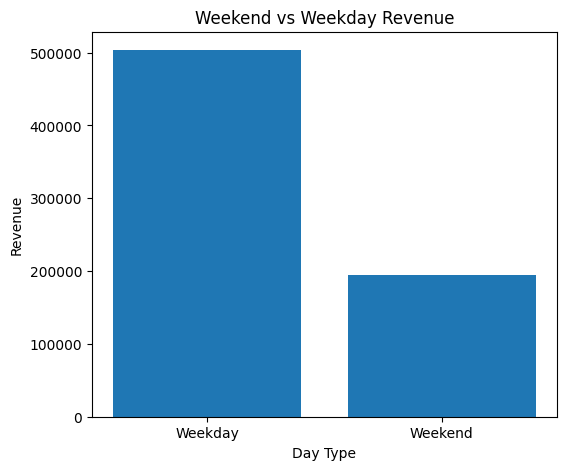

In [79]:
plt.figure(figsize=(6,5))

plt.bar(
    weekend_weekday_revenue['Day_type'],
    weekend_weekday_revenue['Total_Bill']
)

plt.title('Weekend vs Weekday Revenue')
plt.xlabel('Day Type')
plt.ylabel('Revenue')

plt.show()

# Orders comparision :


In [80]:
weekend_weekday_orders = (
    df.groupby('Day_type')['transaction_id']
      .count()
      .reset_index()
)

weekend_weekday_orders

,Day_type,transaction_id
0,Weekday,107510
1,Weekend,41606


# Quantity sold :

In [81]:
weekend_weekday_quantity = (
    df.groupby('Day_type')['transaction_qty']
      .sum()
      .reset_index()
)

weekend_weekday_quantity


,Day_type,transaction_qty
0,Weekday,154674
1,Weekend,59796


In [85]:
df.to_csv("coffee_shop_sales_cleaned.csv", index=False)